# LLM Auction Experiment — Data Analysis

This notebook reads `results.csv` produced by `main.py` and visualizes:
1. Bid vs Value scatter plot with BNE and 45° reference lines
2. Convergence to BNE over rounds
3. Bid ratio (bid/value) over time
4. Cumulative profit per agent
5. Win rate distribution

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

RESULTS_FILE = "results.csv"
N_AGENTS = 4  # must match api.env / main.py setting

df = pd.read_csv(RESULTS_FILE)
print(f"Loaded {len(df)} rows across {df['round'].nunique()} rounds and {df['agent_id'].nunique()} agents.")
df.head(10)

Loaded 200 rows across 50 rounds and 4 agents.


,round,agent_id,persona,value,bid,bid_ratio,bne_bid,won,payoff,winning_bid,cumulative_profit
0,1,0,rational,61.12,45.83,0.7498,45.8435,0,0.00,57.15,0.00
1,1,1,rational,74.55,56.40,0.7565,55.9126,0,0.00,57.15,0.00
2,1,2,rational,76.23,57.15,0.7497,57.1698,1,19.08,57.15,19.08
3,1,3,rational,54.11,40.20,0.7429,40.5827,0,0.00,57.15,0.00
4,2,0,rational,65.91,55.00,0.8345,49.4312,1,10.91,55.00,10.91
5,2,1,rational,56.62,50.20,0.8867,42.4613,0,0.00,55.00,0.00
6,2,2,rational,51.50,38.70,0.7515,38.6224,0,0.00,55.00,19.08
7,2,3,rational,56.00,44.00,0.7857,42.0015,0,0.00,55.00,0.00
8,3,0,rational,73.78,59.50,0.8065,55.3340,1,14.28,59.50,25.19
9,3,1,rational,50.86,48.50,0.9537,38.1421,0,0.00,59.50,0.00


## 1. Bid vs Value — Full Experiment

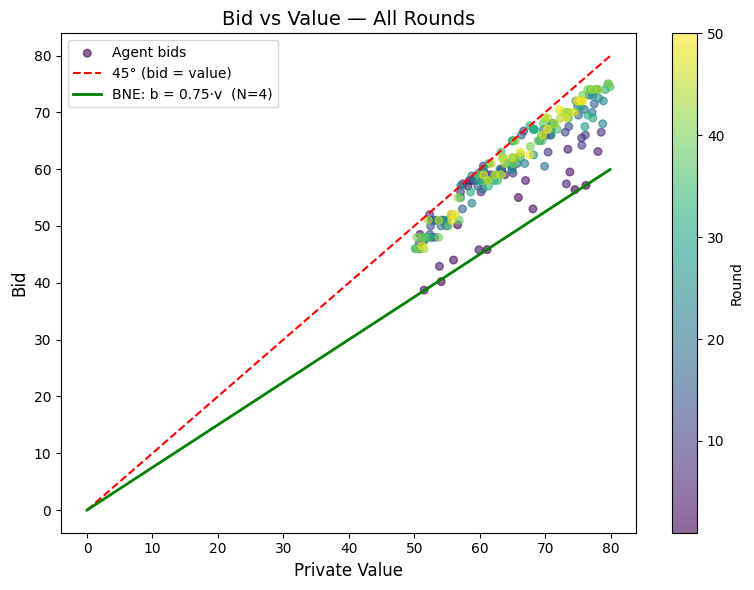

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

# Color points by round number to show temporal evolution
scatter = ax.scatter(
    df["value"], df["bid"],
    c=df["round"], cmap="viridis", alpha=0.6, s=30, label="Agent bids"
)
plt.colorbar(scatter, ax=ax, label="Round")

v_range = np.linspace(0, df["value"].max(), 200)

# 45° honest bidding line
ax.plot(v_range, v_range, "r--", lw=1.5, label="45° (bid = value)")

# BNE line: b* = (N-1)/N * v
bne_slope = (N_AGENTS - 1) / N_AGENTS
ax.plot(v_range, bne_slope * v_range, "g-", lw=2,
        label=f"BNE: b = {bne_slope:.2f}·v  (N={N_AGENTS})")

ax.set_xlabel("Private Value", fontsize=12)
ax.set_ylabel("Bid", fontsize=12)
ax.set_title("Bid vs Value — All Rounds", fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig("plot_bid_vs_value.png", dpi=150)
plt.show()

## 2. Convergence to BNE — Early vs Late Rounds

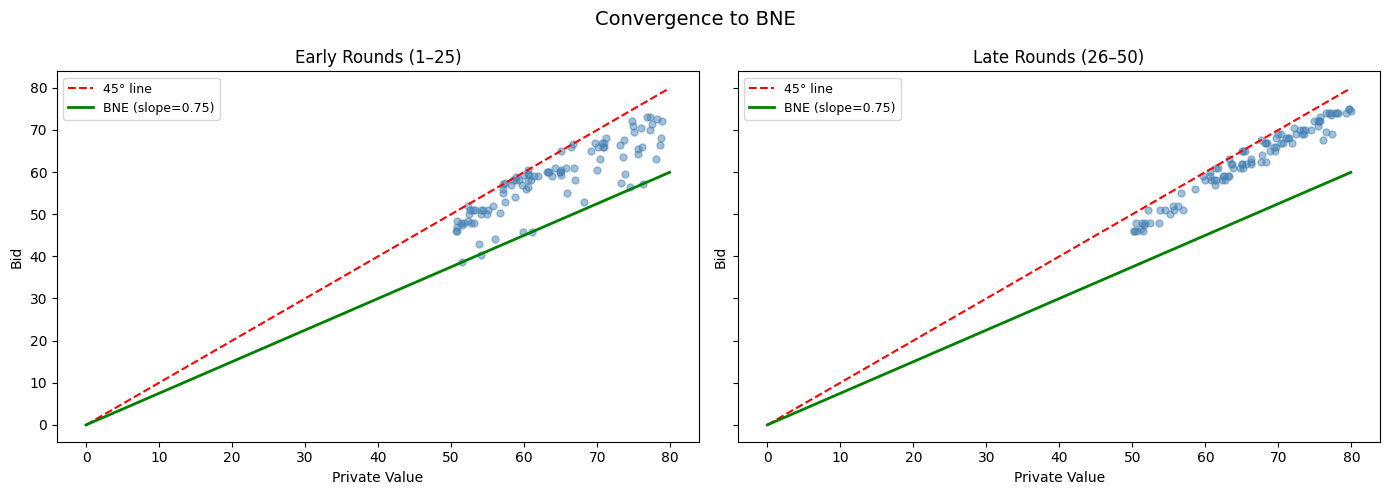

In [38]:
max_round = df["round"].max()
cutoff = max_round // 2

early = df[df["round"] <= cutoff]
late  = df[df["round"] >  cutoff]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, subset, title in zip(axes, [early, late], [f"Early Rounds (1–{cutoff})", f"Late Rounds ({cutoff+1}–{max_round})"]):
    ax.scatter(subset["value"], subset["bid"], alpha=0.5, s=25, color="steelblue")
    ax.plot(v_range, v_range, "r--", lw=1.5, label="45° line")
    ax.plot(v_range, bne_slope * v_range, "g-", lw=2, label=f"BNE (slope={bne_slope:.2f})")
    ax.set_xlabel("Private Value")
    ax.set_ylabel("Bid")
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle("Convergence to BNE", fontsize=14)
plt.tight_layout()
plt.savefig("plot_convergence.png", dpi=150)
plt.show()

## 3. Bid Ratio (bid / value) Over Rounds

The BNE predicts bid_ratio should converge to **(N-1)/N**.

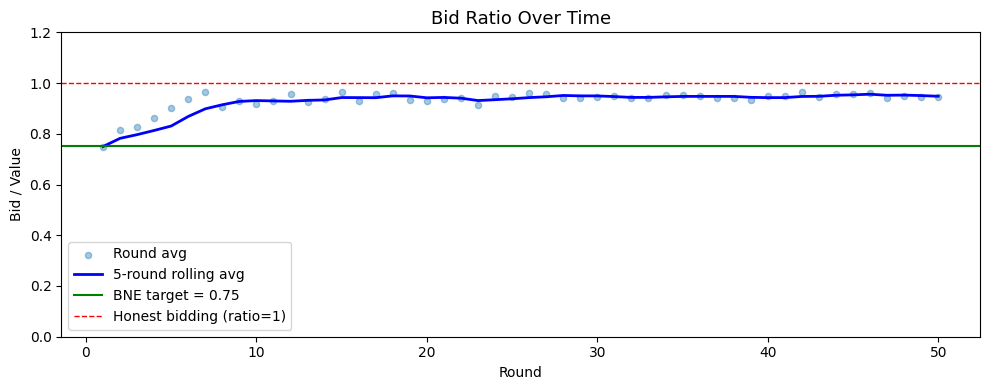

In [39]:
avg_ratio = df.groupby("round")["bid_ratio"].mean()
rolling_avg = avg_ratio.rolling(window=5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(avg_ratio.index, avg_ratio.values, alpha=0.4, s=20, label="Round avg")
ax.plot(rolling_avg.index, rolling_avg.values, "b-", lw=2, label="5-round rolling avg")
ax.axhline(bne_slope, color="green", linestyle="-", lw=1.5,
           label=f"BNE target = {bne_slope:.2f}")
ax.axhline(1.0, color="red", linestyle="--", lw=1, label="Honest bidding (ratio=1)")
ax.set_xlabel("Round")
ax.set_ylabel("Bid / Value")
ax.set_title("Bid Ratio Over Time", fontsize=13)
ax.set_ylim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.savefig("plot_bid_ratio.png", dpi=150)
plt.show()

## 4. Cumulative Profit Per Agent

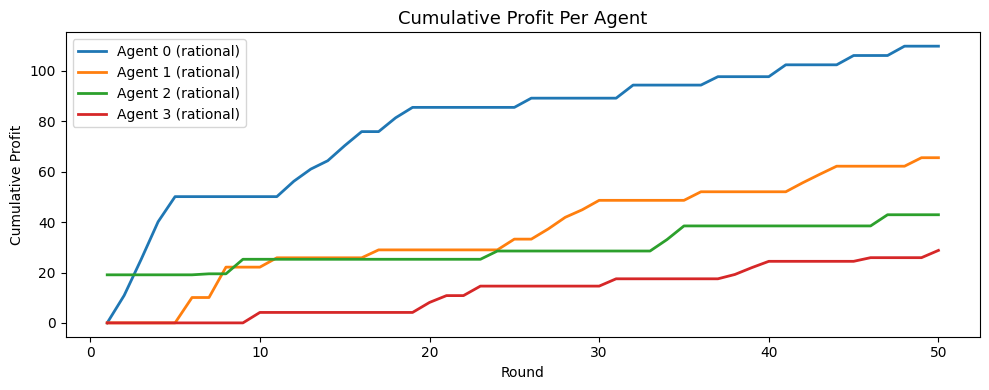

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = cm.tab10.colors

for agent_id, group in df.groupby("agent_id"):
    group = group.sort_values("round")
    persona = group["persona"].iloc[0]
    ax.plot(
        group["round"], group["cumulative_profit"],
        lw=2, color=colors[agent_id],
        label=f"Agent {agent_id} ({persona})"
    )

ax.set_xlabel("Round")
ax.set_ylabel("Cumulative Profit")
ax.set_title("Cumulative Profit Per Agent", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("plot_cumulative_profit.png", dpi=150)
plt.show()

## 5. Summary Statistics

In [41]:
summary = df.groupby(["agent_id", "persona"]).agg(
    avg_bid_ratio=("bid_ratio", "mean"),
    std_bid_ratio=("bid_ratio", "std"),
    win_rate=("won", "mean"),
    total_profit=("payoff", "sum"),
    avg_profit_per_round=("payoff", "mean"),
).round(4)

summary["bne_target"] = bne_slope
summary["ratio_deviation"] = (summary["avg_bid_ratio"] - bne_slope).abs()

print(summary.to_string())
summary

                   avg_bid_ratio  std_bid_ratio  win_rate  total_profit  avg_profit_per_round  bne_target  ratio_deviation
agent_id persona                                                                                                          
0        rational         0.9206         0.0415      0.34        109.86                2.1972        0.75           0.1706
1        rational         0.9384         0.0384      0.28         65.57                1.3114        0.75           0.1884
2        rational         0.9147         0.0599      0.14         42.94                0.8588        0.75           0.1647
3        rational         0.9565         0.0546      0.24         28.79                0.5758        0.75           0.2065


,,avg_bid_ratio,std_bid_ratio,win_rate,total_profit,avg_profit_per_round,bne_target,ratio_deviation
agent_id,persona,,,,,,,
0,rational,0.9206,0.0415,0.34,109.86,2.1972,0.75,0.1706
1,rational,0.9384,0.0384,0.28,65.57,1.3114,0.75,0.1884
2,rational,0.9147,0.0599,0.14,42.94,0.8588,0.75,0.1647
3,rational,0.9565,0.0546,0.24,28.79,0.5758,0.75,0.2065


In [42]:
# Late-round average bid ratio vs BNE benchmark
late_ratio = df[df["round"] > cutoff]["bid_ratio"].mean()
print(f"Late-round average bid ratio : {late_ratio:.4f}")
print(f"BNE theoretical target       : {bne_slope:.4f}")
print(f"Deviation                    : {abs(late_ratio - bne_slope):.4f}")

Late-round average bid ratio : 0.9482
BNE theoretical target       : 0.7500
Deviation                    : 0.1982
